# Neural Network Regularization

Deep neural networks can have millions of parameters and easily *memorize* the training set. When this happens, the model performs very well on the data it has seen but generalizes poorly to new examples — this is **overfitting**.

**Regularization** is a family of techniques that gently constrains a model so it learns *patterns* instead of memorizing noise.

In this notebook we look at the three most common regularization techniques used in PyTorch:

1. **L1 regularization (Lasso)** — adds the sum of *absolute* weights to the loss.
2. **L2 regularization (Ridge / weight decay)** — adds the sum of *squared* weights to the loss.
3. **Dropout** — randomly switches off neurons during training so the network cannot rely on any single one.

We deliberately set up a **heavy-overfitting scenario** (very small training set, very large network, aggressive optimizer, long training) so the value of each technique is visually obvious.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Reproducibility for the whole notebook
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


/home/erradi/.venvs/ml-env/lib/python3.14/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## A small but realistic dataset

We use `make_moons` from scikit-learn — two interlocking half-moons with **a lot** of noise. It is non-linear (so a real neural network is justified) but still 2-D, so we can *see* the decision boundary.

To make overfitting dramatic we keep only **50 training points** while testing on **350**. With this little data, an over-sized network has more than enough capacity to *memorize* the train set — exactly the regime where regularization matters.


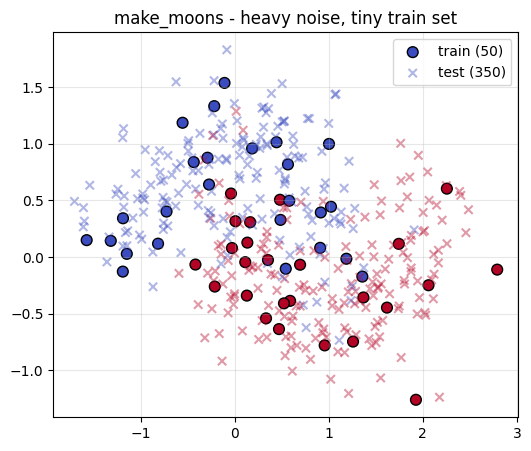

In [2]:
# Two interlocking moons with heavy noise -> realistic, hard to fit cleanly
X, y = make_moons(n_samples=400, noise=0.35, random_state=0)

# Tiny training set on purpose: forces the over-sized model to overfit hard
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=50, random_state=0, stratify=y
)

# Convert numpy arrays to tensors on the right device
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long,    device=device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long,    device=device)

# Quick visualization
plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm",
            edgecolor="k", s=60, label="train (50)")
plt.scatter(X_test[:, 0],  X_test[:, 1],  c=y_test,  cmap="coolwarm",
            marker="x", alpha=0.4, label=f"test ({len(X_test)})")
plt.title("make_moons - heavy noise, tiny train set")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## A deliberately over-sized baseline model

We use a **very wide** MLP (3 hidden layers of **256** units = roughly 130k parameters) for a tiny 2-D problem with only 50 training points. This network has *thousands* of times more parameters than data points — the textbook setup for overfitting.

We also switch to the **Adam** optimizer and train for **2000 epochs**: Adam adapts each weight's learning rate individually, which makes it much faster and more aggressive at memorizing the training data than plain SGD.

The same `MLP` class is used for every experiment. The only thing that changes between experiments is **how we regularize it**:

* nothing → baseline,
* a manual L1 term in the loss,
* `weight_decay` in the optimizer (= L2),
* a non-zero dropout probability inside the model.


In [3]:
class MLP(nn.Module):
    # Configurable MLP used for every experiment in this notebook.
    def __init__(self, dropout: float = 0.0, hidden: int = 256):
        super().__init__()
        # nn.Dropout(0.0) is a no-op, so the same class works with or without dropout
        self.net = nn.Sequential(
            nn.Linear(2, hidden),       nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 2),       # 2 logits = 2 classes
        )

    def forward(self, x):
        return self.net(x)


def train(model, *, epochs=2000, lr=1e-2, weight_decay=0.0, l1_lambda=0.0):
    # Train ``model`` and return the train/test loss curves.
    #   weight_decay > 0 -> L2 regularization (handled by the optimizer).
    #   l1_lambda    > 0 -> L1 regularization (added manually to the loss).
    model.to(device)
    # Adam adapts per-parameter learning rates -> overfits aggressively unless
    # regularized, which is exactly the behaviour we want to demonstrate.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_losses = [], []
    for _ in range(epochs):
        # --- training step ---
        model.train()                     # enables dropout (if any)
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)

        # L1 has no built-in optimizer support, so we add the penalty by hand
        if l1_lambda > 0:
            l1 = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lambda * l1

        loss.backward()
        optimizer.step()

        # --- track metrics on full train / test (no grad, no dropout) ---
        model.eval()
        with torch.no_grad():
            train_losses.append(criterion(model(X_train_t), y_train_t).item())
            test_losses.append(criterion(model(X_test_t),  y_test_t ).item())

    return train_losses, test_losses


def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        return (model(X).argmax(dim=1) == y).float().mean().item()


def plot_curves(curves, title):
    # ``curves`` is a dict: name -> (train_losses, test_losses)
    plt.figure(figsize=(7, 4))
    for name, (tr, te) in curves.items():
        plt.plot(tr, linestyle="--", label=f"{name} train")
        plt.plot(te,                 label=f"{name} test")
    plt.xlabel("epoch"); plt.ylabel("cross-entropy loss")
    plt.title(title); plt.legend(); plt.grid(alpha=0.3); plt.show()


print(f"model parameter count = {sum(p.numel() for p in MLP().parameters()):,}")
print(f"training samples      = {len(X_train_t)}")


model parameter count = 132,866
training samples      = 50


### Baseline — no regularization

Watch the **test loss**: it falls briefly, then climbs steadily upward while the **train loss** keeps dropping toward zero. That widening gap is the unmistakable signature of overfitting — the model is memorizing the noise in the 50 training points.


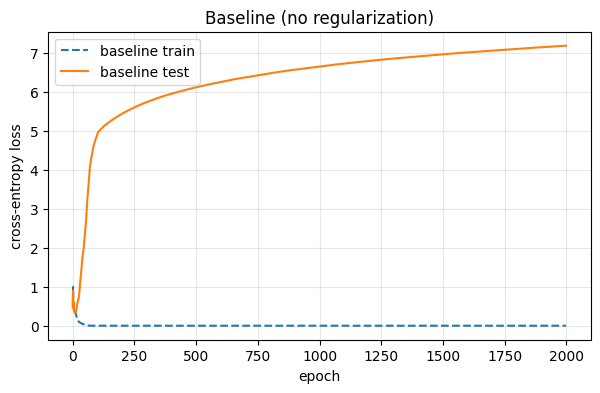

train acc = 1.000
test  acc = 0.811


In [4]:
torch.manual_seed(0)
baseline = MLP(dropout=0.0)
tr_base, te_base = train(baseline)

plot_curves({"baseline": (tr_base, te_base)}, "Baseline (no regularization)")
print(f"train acc = {accuracy(baseline, X_train_t, y_train_t):.3f}")
print(f"test  acc = {accuracy(baseline, X_test_t,  y_test_t ):.3f}")


## 1. L1 Regularization (Lasso)

L1 adds the **sum of absolute values** of all weights to the loss:

$$\mathcal{L}_{\text{total}} \;=\; \mathcal{L}_{\text{data}} \;+\; \lambda \sum_i |w_i|$$

Key properties:

* The gradient of $|w|$ has constant magnitude regardless of how small $w$ is, so L1 keeps pushing small weights **all the way to exactly zero**.
* The result is a **sparse** model: many weights end up at 0, effectively performing built-in *feature / connection selection*.
* Use it when you suspect that only a few inputs / connections actually matter, or when you want a smaller, more interpretable model.

PyTorch has no built-in L1 option, so we add the penalty manually inside the training loop (`l1_lambda` in our `train` function).


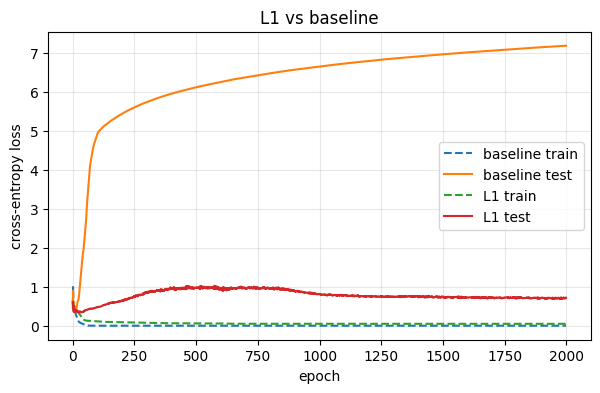

L1 train acc = 0.960
L1 test  acc = 0.843
fraction of (near-)zero weights = 50.50%


In [5]:
torch.manual_seed(0)
model_l1 = MLP(dropout=0.0)

# l1_lambda controls the strength of the penalty. With ~130k parameters in a
# tiny dataset, we need a clearly non-trivial value to drive most weights to 0.
tr_l1, te_l1 = train(model_l1, l1_lambda=2e-3)

plot_curves(
    {"baseline": (tr_base, te_base), "L1": (tr_l1, te_l1)},
    "L1 vs baseline",
)

# Sparsity check: how many weights are (almost) zero after L1?
all_w = torch.cat([p.detach().flatten() for p in model_l1.parameters()])
sparsity = (all_w.abs() < 1e-3).float().mean().item()

print(f"L1 train acc = {accuracy(model_l1, X_train_t, y_train_t):.3f}")
print(f"L1 test  acc = {accuracy(model_l1, X_test_t,  y_test_t ):.3f}")
print(f"fraction of (near-)zero weights = {sparsity:.2%}")


## 2. L2 Regularization (Ridge / Weight Decay)

L2 adds the **sum of squared weights** to the loss:

$$\mathcal{L}_{\text{total}} \;=\; \mathcal{L}_{\text{data}} \;+\; \lambda \sum_i w_i^{\,2}$$

Key properties:

* The gradient of $w^2$ is $2w$, so L2 *shrinks* weights smoothly toward zero **without forcing them all the way to 0**.
* It produces *small, distributed* weights — the network avoids relying on any single huge weight.
* This is by far the most common regularizer in deep learning. In PyTorch it is built into every optimizer as the **`weight_decay`** argument — no manual penalty needed.


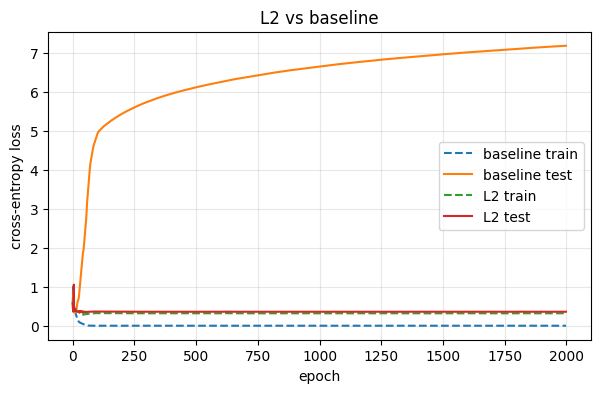

L2 train acc = 0.880
L2 test  acc = 0.860
mean |w|: baseline = 0.058   L2 = 0.001


In [6]:
torch.manual_seed(0)
model_l2 = MLP(dropout=0.0)

# weight_decay handles the L2 penalty directly inside the optimizer
tr_l2, te_l2 = train(model_l2, weight_decay=5e-2)

plot_curves(
    {"baseline": (tr_base, te_base), "L2": (tr_l2, te_l2)},
    "L2 vs baseline",
)

print(f"L2 train acc = {accuracy(model_l2, X_train_t, y_train_t):.3f}")
print(f"L2 test  acc = {accuracy(model_l2, X_test_t,  y_test_t ):.3f}")

# Compare typical weight magnitudes vs the unregularized baseline
mag_base = torch.cat([p.detach().flatten() for p in baseline.parameters()]).abs().mean()
mag_l2   = torch.cat([p.detach().flatten() for p in model_l2.parameters()]).abs().mean()
print(f"mean |w|: baseline = {mag_base:.3f}   L2 = {mag_l2:.3f}")


## 3. Dropout

During **training**, dropout randomly sets a fraction `p` of activations to zero on each forward pass. At **evaluation** time dropout is turned off and the full network is used.

Why it works:

* The network can no longer rely on any specific neuron, so information is forced to spread across many units (no co-adaptation).
* It is mathematically similar to training a huge **ensemble** of thinner sub-networks and averaging them at test time.

Implementation in PyTorch is just `nn.Dropout(p)`. Two important details:

* Always toggle `model.train()` / `model.eval()` so dropout is active only during training.
* Typical values are `p = 0.2`–`0.5` for hidden layers in MLPs / CNNs.


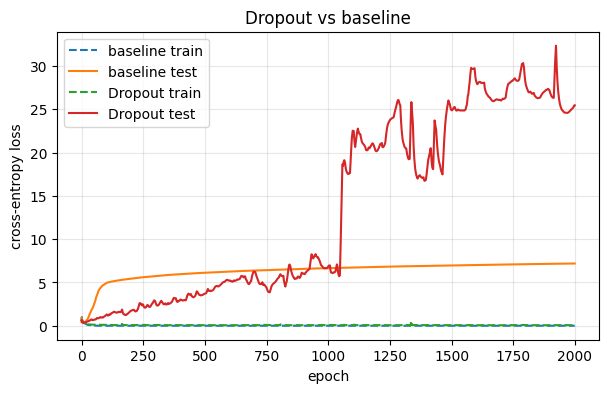

Dropout train acc = 0.980
Dropout test  acc = 0.866


In [7]:
torch.manual_seed(0)
# Aggressive dropout (p=0.5) because the network is hugely over-parameterized.
# Our MLP class already inserts nn.Dropout(p) between hidden layers.
model_do = MLP(dropout=0.5)
tr_do, te_do = train(model_do)

plot_curves(
    {"baseline": (tr_base, te_base), "Dropout": (tr_do, te_do)},
    "Dropout vs baseline",
)

print(f"Dropout train acc = {accuracy(model_do, X_train_t, y_train_t):.3f}")
print(f"Dropout test  acc = {accuracy(model_do, X_test_t,  y_test_t ):.3f}")


## Putting them side by side

A summary table and the **decision boundaries** make the difference visual. We overlay the **test points** on each boundary plot — points that fall in the wrong colored region are misclassifications, so you can literally *see* the generalization gap shrink as we add regularization.

The baseline carves a wiggly boundary that hugs every training point (memorization). The regularized models produce smoother boundaries that follow the *shape* of the data — exactly what we want.


model        train    test     gap
baseline     1.000   0.811  +0.189
L1           0.960   0.843  +0.117
L2           0.880   0.860  +0.020
Dropout      0.980   0.866  +0.114


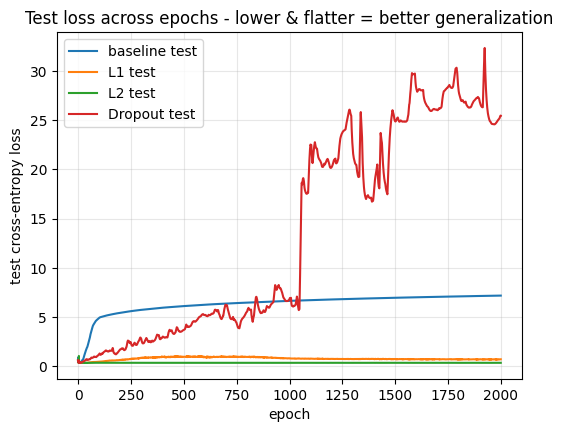

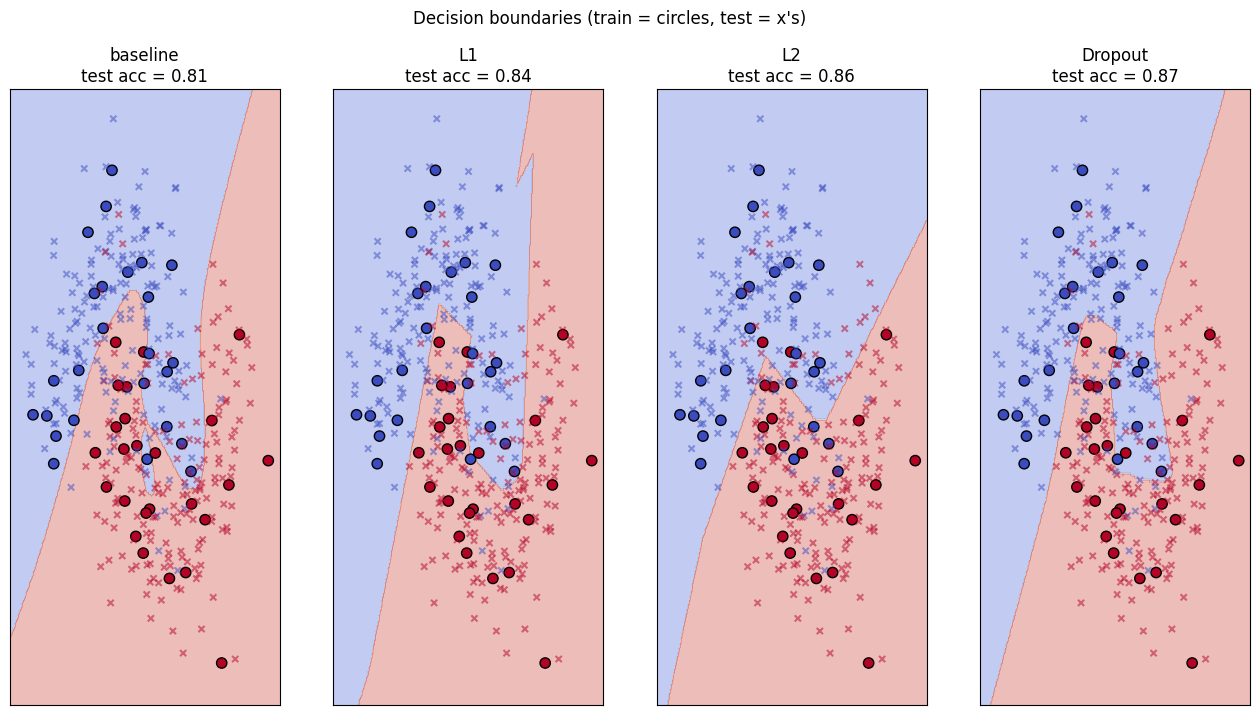

In [10]:
results = {
    "baseline": (baseline, (tr_base, te_base)),
    "L1":       (model_l1, (tr_l1,   te_l1)),
    "L2":       (model_l2, (tr_l2,   te_l2)),
    "Dropout":  (model_do, (tr_do,   te_do)),
}

# --- Train / test accuracy summary (and the all-important gap) ---
print(f"{'model':10s} {'train':>7s} {'test':>7s} {'gap':>7s}")
for name, (m, _) in results.items():
    a_tr = accuracy(m, X_train_t, y_train_t)
    a_te = accuracy(m, X_test_t,  y_test_t)
    print(f"{name:10s} {a_tr:7.3f} {a_te:7.3f} {a_tr - a_te:+7.3f}")

# --- All loss curves on one plot to compare overfitting visually ---
plt.figure(figsize=(6, 4.5))
for name, (_, (tr, te)) in results.items():
    plt.plot(te, label=f"{name} test")
plt.xlabel("epoch"); plt.ylabel("test cross-entropy loss")
plt.title("Test loss across epochs - lower & flatter = better generalization")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# --- Decision boundaries with TEST points overlaid (mistakes are visible) ---
xx, yy = np.meshgrid(np.linspace(-2.0, 3.0, 300),
                     np.linspace(-1.5, 2.0, 300))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()],
                    dtype=torch.float32, device=device)

fig, axes = plt.subplots(1, 4, figsize=(16, 8))
for ax, (name, (m, _)) in zip(axes, results.items()):
    m.eval()
    with torch.no_grad():
        Z = m(grid).argmax(dim=1).cpu().numpy().reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap="coolwarm")
    # Train points (filled circles, big) and test points (small x's)
    ax.scatter(X_train[:, 0], X_train[:, 1],
               c=y_train, cmap="coolwarm", edgecolor="k", s=55, label="train")
    ax.scatter(X_test[:, 0], X_test[:, 1],
               c=y_test, cmap="coolwarm", marker="x", alpha=0.5, s=20, label="test")
    a_te = accuracy(m, X_test_t, y_test_t)
    ax.set_title(f"{name}\ntest acc = {a_te:.2f}")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Decision boundaries (train = circles, test = x's)")
plt.show()


## How to choose between L1, L2 and Dropout

There is no universal winner — the right tool depends on **what you suspect is causing the overfitting** and on the **type of model** you are training.

| Technique | What it does | When to reach for it |
|---|---|---|
| **L2** (`weight_decay`) | Shrinks every weight smoothly toward zero. | **Default first choice.** Stable, one optimizer argument, works with almost any architecture. |
| **L1** | Pushes many weights to *exactly* zero (sparse model). | When you want feature / connection selection, a smaller / more interpretable model, or you suspect only a few inputs really matter. |
| **Dropout** | Randomly zeroes activations during training. | **Large neural networks** (deep MLPs, CNNs, Transformers) where weight shrinkage alone is not enough. |

A practical recipe:

1. **Start with L2** (`weight_decay` between `1e-4` and `1e-2`). It almost always helps and costs you nothing.
2. If the network is **deep** and still overfits, **add Dropout** (`p ≈ 0.2 – 0.5`) to the hidden layers.
3. Use **L1** when you specifically want **sparsity / feature selection**, or combine L1 + L2 ("Elastic Net") to get both shrinkage and sparsity.
4. **Tune the strength** ($\lambda$, `weight_decay`, dropout `p`) on a **validation set** — too much regularization causes *under*fitting (both train and test loss stay high).
5. Regularization is **not a silver bullet**. More / cleaner data, **early stopping**, and **data augmentation** are equally important tools against overfitting and often complement these three techniques.
